<a href="https://colab.research.google.com/github/SriVyshnavi11/FOUNDATIONS-OF-DATA-SCIENCE-/blob/main/exp1titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape of Dataset: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Inform

/tmp/ipykernel_2007/886017236.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic[col].fillna(titanic[col].mean(), inplace=True)
/tmp/ipykernel_2007/886017236.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

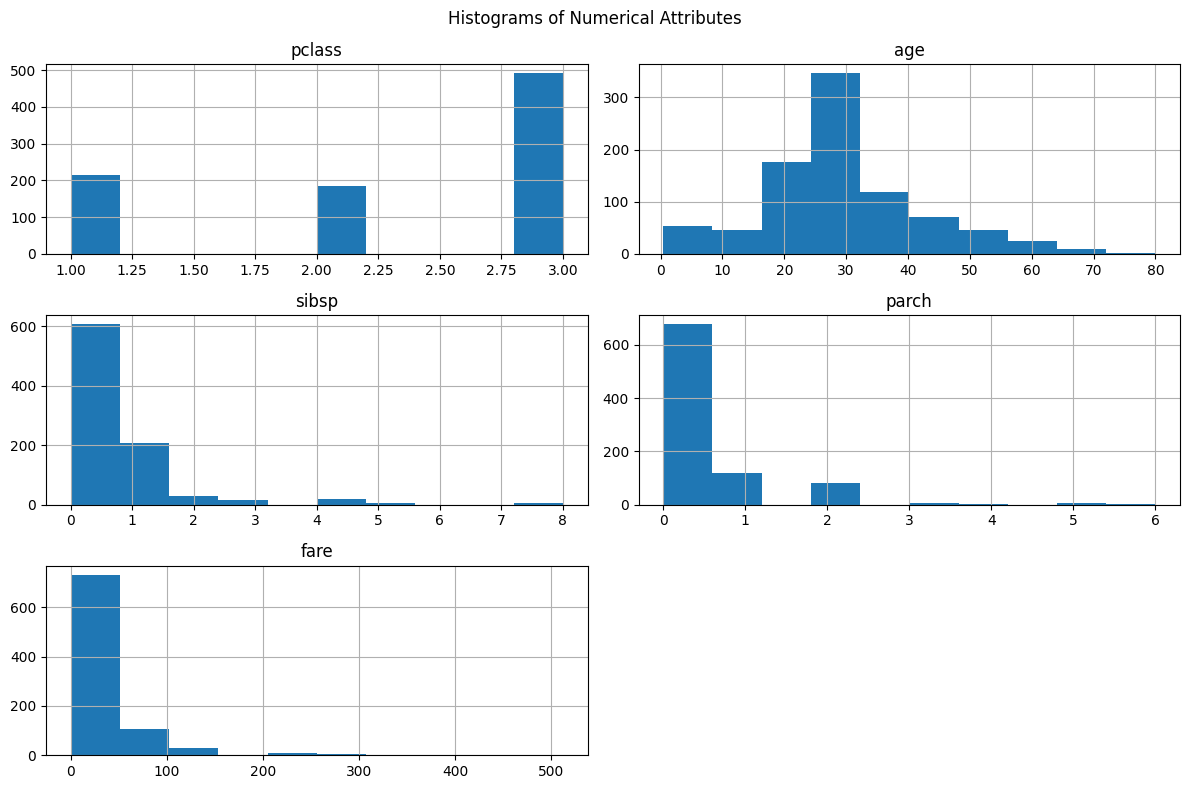

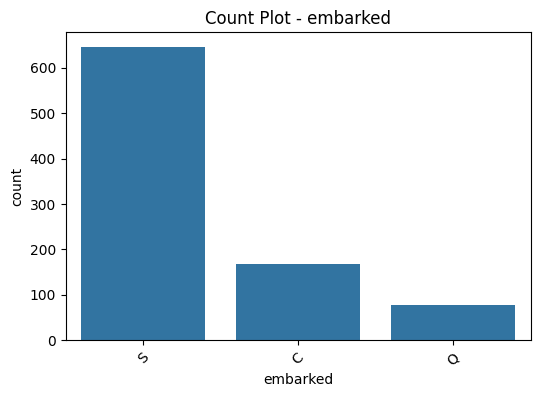

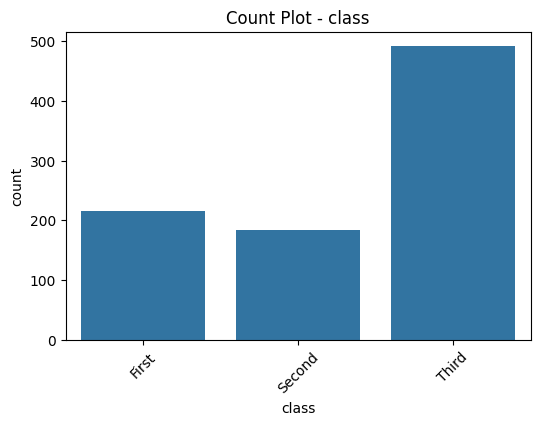

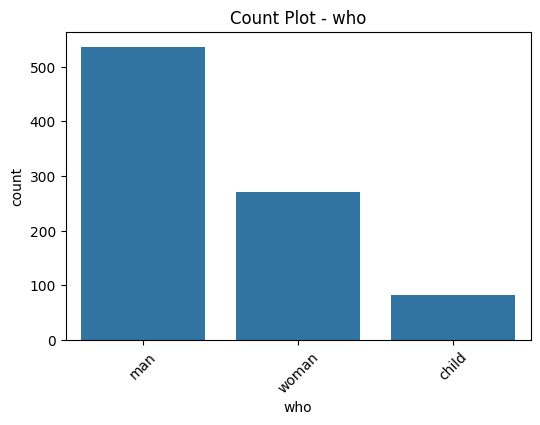

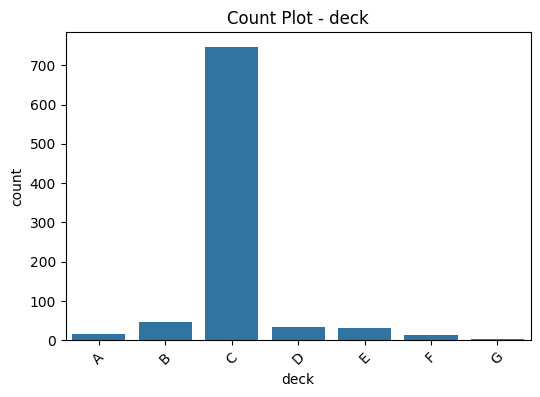

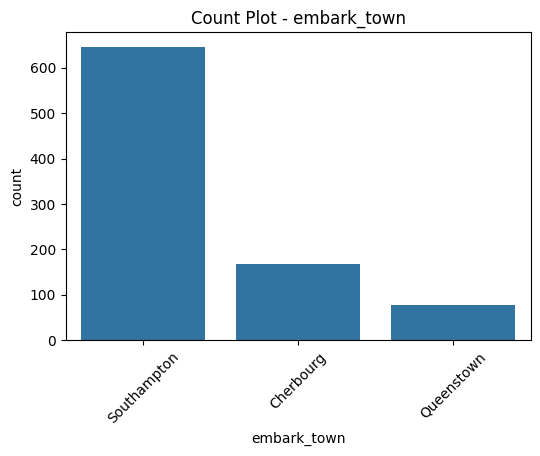

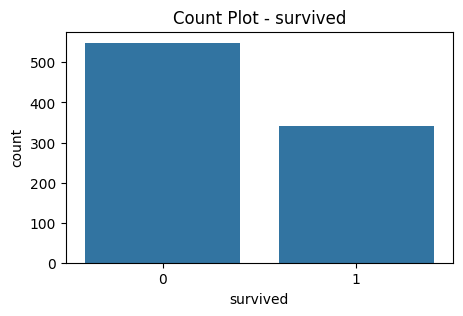

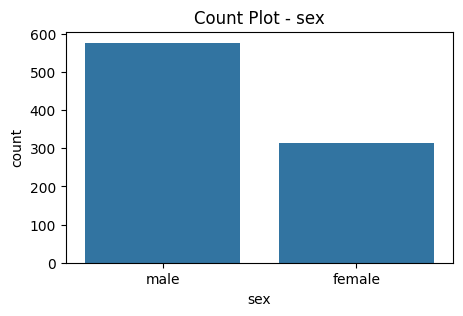

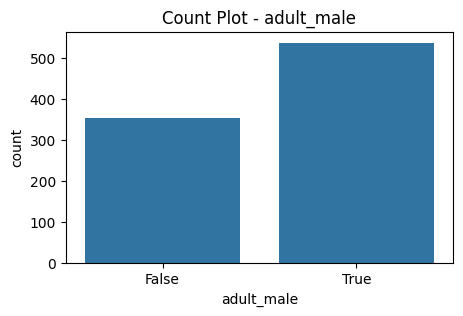

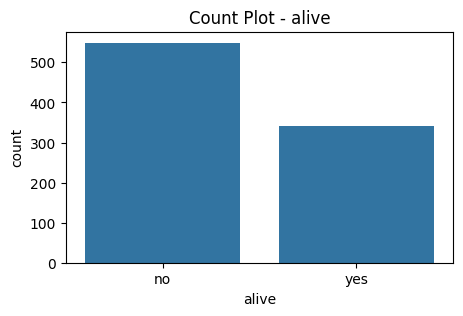

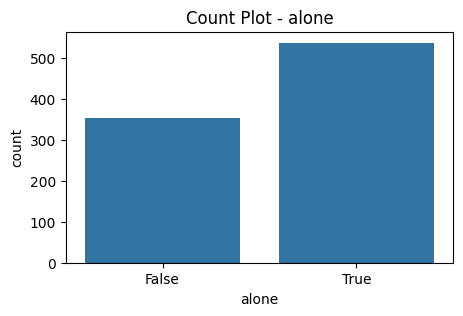

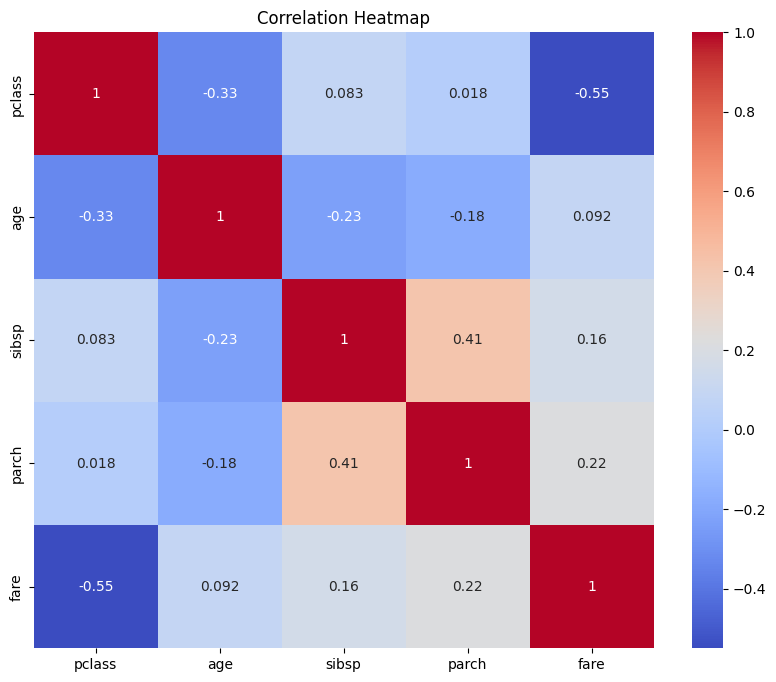

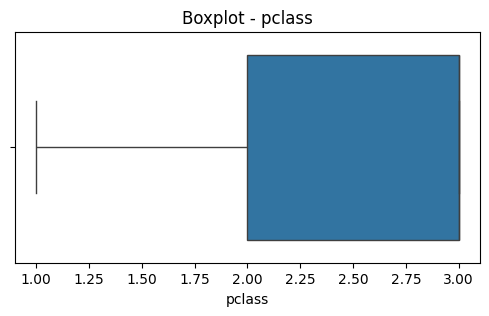

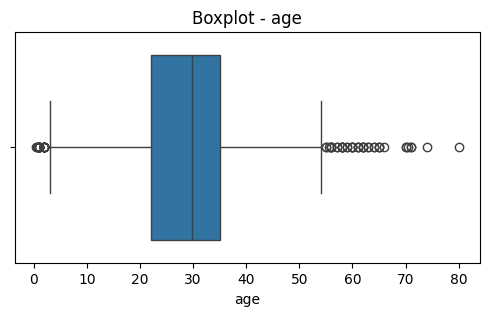

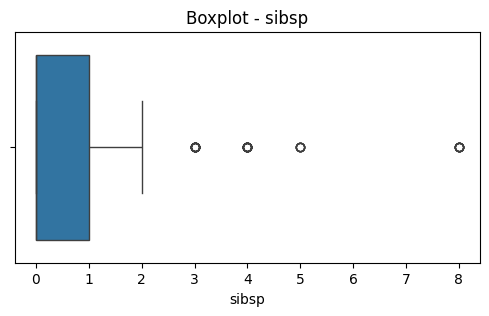

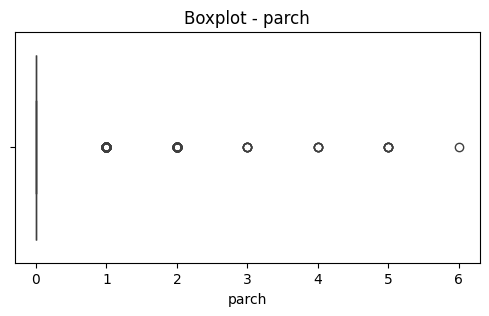

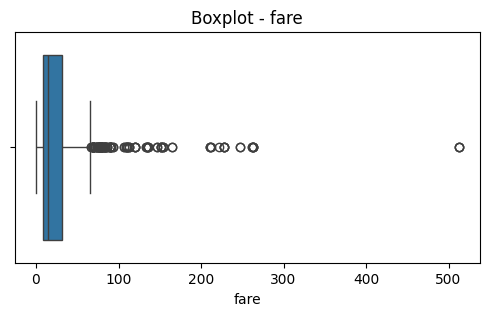


Data Preprocessing Completed Successfully!


In [6]:
# ============================
# TITANIC DATA PREPROCESSING
# ============================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic Dataset
titanic = sns.load_dataset('titanic')

# Display Dataset
print("First 5 Rows:")
print(titanic.head())

# ----------------------------
# Basic EDA
# ----------------------------
print("\nShape of Dataset:", titanic.shape)

print("\nColumn Names:")
print(titanic.columns.tolist())

print("\nDataset Information:")
titanic.info()

print("\nSummary Statistics:")
print(titanic.describe(include='all'))

print("\nMissing Values Before Filling:")
print(titanic.isnull().sum())

print("\nDuplicate Rows:", titanic.duplicated().sum())

# ----------------------------
# Identify Attribute Types
# ----------------------------
numerical = []
nominal = []
binary = []

for col in titanic.columns:
    if titanic[col].nunique(dropna=True) == 2:
        binary.append(col)
    elif pd.api.types.is_numeric_dtype(titanic[col]):
        numerical.append(col)
    else:
        nominal.append(col)

print("\nNumerical Attributes:")
print(numerical)

print("\nNominal Attributes:")
print(nominal)

print("\nBinary Attributes:")
print(binary)

# ----------------------------
# Fill Missing Values
# ----------------------------
for col in titanic.columns:
    if titanic[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(titanic[col]):
            titanic[col].fillna(titanic[col].mean(), inplace=True)
        else:
            titanic[col].fillna(titanic[col].mode()[0], inplace=True)

print("\nMissing Values After Filling:")
print(titanic.isnull().sum())

# ----------------------------
# Histograms for Numerical Attributes
# ----------------------------
titanic[numerical].hist(figsize=(12,8))
plt.suptitle("Histograms of Numerical Attributes")
plt.tight_layout()
plt.show()

# ----------------------------
# Count Plots for Nominal Attributes
# ----------------------------
for col in nominal:
    plt.figure(figsize=(6,4))
    sns.countplot(data=titanic, x=col)
    plt.title(f"Count Plot - {col}")
    plt.xticks(rotation=45)
    plt.show()

# ----------------------------
# Count Plots for Binary Attributes
# ----------------------------
for col in binary:
    plt.figure(figsize=(5,3))
    sns.countplot(data=titanic, x=col)
    plt.title(f"Count Plot - {col}")
    plt.show()

# ----------------------------
# Correlation Heatmap
# ----------------------------
plt.figure(figsize=(10,8))
sns.heatmap(titanic[numerical].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------
# Boxplots for Numerical Attributes
# ----------------------------
for col in numerical:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=titanic[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

print("\nData Preprocessing Completed Successfully!")

In [7]:
# ----------------------------
# Measure Data Dissimilarity
# ----------------------------

from scipy.spatial.distance import hamming, euclidean

# Select first two nominal and numerical attributes
nominal_cols = nominal[:2]
numerical_cols = numerical[:2]

print("\nSelected Nominal Attributes:", nominal_cols)
print("Selected Numerical Attributes:", numerical_cols)

# Take first two records
row1 = titanic.iloc[0]
row2 = titanic.iloc[1]

# Nominal Dissimilarity (Hamming Distance)
nominal_distance = hamming(
    row1[nominal_cols].astype(str),
    row2[nominal_cols].astype(str)
)

print("\nNominal Attribute Dissimilarity (Hamming Distance):")
print(nominal_distance)

# Numerical Dissimilarity (Euclidean Distance)
numeric_distance = euclidean(
    row1[numerical_cols],
    row2[numerical_cols]
)

print("\nNumerical Attribute Dissimilarity (Euclidean Distance):")
print(numeric_distance)


Selected Nominal Attributes: ['embarked', 'class']
Selected Numerical Attributes: ['pclass', 'age']

Nominal Attribute Dissimilarity (Hamming Distance):
1.0

Numerical Attribute Dissimilarity (Euclidean Distance):
16.1245154965971


In [8]:
# ----------------------------
# Measure Similarity & Dissimilarity
# ----------------------------

from scipy.spatial.distance import hamming, euclidean, cityblock, minkowski
from sklearn.metrics.pairwise import cosine_similarity

# Select first two nominal and numerical attributes
nominal_cols = nominal[:2]
numerical_cols = numerical[:2]

print("Selected Nominal Attributes:", nominal_cols)
print("Selected Numerical Attributes:", numerical_cols)

# Select first two records
row1 = titanic.iloc[0]
row2 = titanic.iloc[1]

# ============================
# NOMINAL ATTRIBUTES
# ============================

# Hamming Distance (Dissimilarity)
nominal_dissimilarity = hamming(
    row1[nominal_cols].astype(str),
    row2[nominal_cols].astype(str)
)

# Matching Coefficient (Similarity)
nominal_similarity = (
    row1[nominal_cols].astype(str) ==
    row2[nominal_cols].astype(str)
).mean()

print("\n----- Nominal Attributes -----")
print("Hamming Distance (Dissimilarity):", nominal_dissimilarity)
print("Matching Similarity:", nominal_similarity)

# ============================
# NUMERICAL ATTRIBUTES
# ============================

num1 = row1[numerical_cols].values.reshape(1, -1)
num2 = row2[numerical_cols].values.reshape(1, -1)

# Euclidean Distance
euclidean_dist = euclidean(num1.flatten(), num2.flatten())

# Manhattan Distance
manhattan_dist = cityblock(num1.flatten(), num2.flatten())

# Minkowski Distance (p=3)
minkowski_dist = minkowski(num1.flatten(), num2.flatten(), p=3)

# Cosine Similarity
cos_sim = cosine_similarity(num1, num2)[0][0]

print("\n----- Numerical Attributes -----")
print("Euclidean Distance:", euclidean_dist)
print("Manhattan Distance:", manhattan_dist)
print("Minkowski Distance (p=3):", minkowski_dist)
print("Cosine Similarity:", cos_sim)

Selected Nominal Attributes: ['embarked', 'class']
Selected Numerical Attributes: ['pclass', 'age']

----- Nominal Attributes -----
Hamming Distance (Dissimilarity): 1.0
Matching Similarity: 0.0

----- Numerical Attributes -----
Euclidean Distance: 16.1245154965971
Manhattan Distance: 18.0
Minkowski Distance (p=3): 16.010409892331666
Cosine Similarity: 0.9940416410213652
